In [1]:
import os

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
from dotenv import load_dotenv
from statsmodels.stats.anova import AnovaRM

from multipred.plotting import barplot_morey, barplot_morey_maineffect

In [2]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data"
ROI, MOD_PRED = "A1", "Auditory" # ROI mask to use, and modality of which we want assess prediction effects
SUBJLIST = [subj for subj in os.listdir(DATA_PATH) if "sub-" in subj]; SUBJLIST.sort()
SUBJLIST.remove("sub-15")

## Visual expectation

In [3]:
# Extract average beta values from the EVC of second-level copes for each subject 
df = []
for subj in SUBJLIST:
    # Load the mask
    mask_path = f"{DATA_PATH}/derivatives/masks/{subj}/{ROI}/MNI_space/{subj}_{ROI}.nii.gz"
    mask = nib.load(mask_path).get_fdata()

    for i, attended_modality in enumerate(["all", "visual", "auditory"]):
        runs_contrast = str(i+1)

        for a_pred in [0, 1]:
            if a_pred == 1: 
                cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/old/{subj}/{subj}_task-main.gfeat/cope5.feat/stats/cope{runs_contrast}.nii.gz" # cope 5 for auditory EXP beta map
            else:
                cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/old/{subj}/{subj}_task-main.gfeat/cope6.feat/stats/cope{runs_contrast}.nii.gz" # cope 6 for auditory UEX beta map

            # Load the cope
            cope = nib.load(cope_path).get_fdata()/100
            # Get the mean of the cope within the mask
            mean_ROI = np.mean(cope[mask>0])
            std_ROI = np.std(cope[mask>0])

            df.append({"subj":subj, "a_pred":a_pred, "attended_modality":attended_modality, "mean":mean_ROI, "std":std_ROI})

df = pd.DataFrame(df)

/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

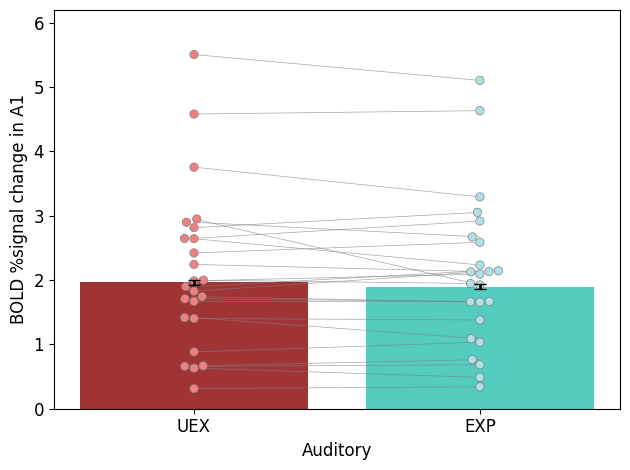

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.14404,24,two-sided,0.26389,"[-0.05, 0.19]",0.045762,0.379,0.055553


In [4]:
x = "a_pred"
y = "mean"
barplot_morey_maineffect(df[df["attended_modality"] == "all"], x, y, ["firebrick", "turquoise"], ["lightcoral", "powderblue"], barplot_plot=True, swarmplot_plot=True, within_lines=True)
plt.ylabel(f"BOLD %signal change in {ROI}")
plt.xlabel(f"{MOD_PRED}")
plt.xticks([0, 1], ["UEX", "EXP"])
plt.ylim(0, 6.2)
plt.tight_layout()
#plt.savefig(f"figures/ROI/{ROI}_allruns.svg", dpi=300)
plt.show()
# rm t-test for the effect of v_pred on mean
a = df[(df["attended_modality"] == "all") & (df["a_pred"] == 0)]["mean"].values
b = df[(df["attended_modality"] == "all") & (df["a_pred"] == 1)]["mean"].values
pg.ttest(a, b, paired=True)

/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

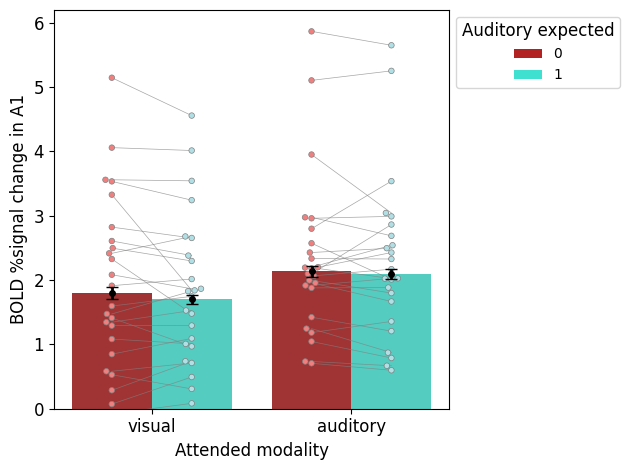

                       Source        SS  ddof1  ddof2        MS          F  \
0           attended_modality  3.415552      1     24  3.415552  10.332409   
1                      a_pred  0.111536      1     24  0.111536   1.308826   
2  attended_modality * a_pred  0.023904      1     24  0.023904   0.351588   

      p-unc  p-GG-corr       ng2  eps  
0  0.003709   0.003709  0.015703  1.0  
1  0.263890   0.263890  0.000521  1.0  
2  0.558762   0.558762  0.000112  1.0  


/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Contrast,attended_modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,attended_modality,-,auditory,visual,True,True,3.214406,24.0,two-sided,0.003709,NaN,NaN,11.114,0.245745
1,a_pred,-,0,1,True,True,1.144039,24.0,two-sided,0.263890,NaN,NaN,0.379,0.045043
2,attended_modality * a_pred,auditory,0,1,True,True,0.502529,24.0,two-sided,0.619875,0.619875,fdr_bh,0.237,0.022881
3,attended_modality * a_pred,visual,0,1,True,True,1.154730,24.0,two-sided,0.259570,0.519139,fdr_bh,0.383,0.066706


In [7]:
x = "attended_modality"
y = "mean"
hue = "a_pred"
dat = df[df["attended_modality"] != "all"]
barplot_morey(dat, x, y, hue, f"{MOD_PRED} expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], barplot_plot=True, swarmplot_plot=True, within_lines=True)
plt.ylabel(f"BOLD %signal change in {ROI}")
plt.xlabel("Attended modality")
plt.ylim(0, 6.2)
plt.tight_layout()
plt.savefig(f"figures/ROI/{ROI}_attention.svg", dpi=300)

plt.show()
print(pg.rm_anova(dv=y, within=[x, hue], subject='subj', data=dat))
pg.pairwise_tests(dv=y, within=[x, hue], subject='subj', data=dat, padjust='fdr_bh')

In [6]:
pg.pairwise_tests(dv=y, within=[x, hue], subject='subj', data=df[df[x] != "all"], padjust='fdr_bh')

,Contrast,attended_modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,attended_modality,-,auditory,visual,True,True,3.214406,24.0,two-sided,0.003709,NaN,NaN,11.114,0.245745
1,v_pred,-,0,1,True,True,1.144039,24.0,two-sided,0.263890,NaN,NaN,0.379,0.045043
2,attended_modality * v_pred,auditory,0,1,True,True,0.502529,24.0,two-sided,0.619875,0.619875,fdr_bh,0.237,0.022881
3,attended_modality * v_pred,visual,0,1,True,True,1.154730,24.0,two-sided,0.259570,0.519139,fdr_bh,0.383,0.066706


### visual * auditory prediction

In [19]:
crossmodal_df = []
for subj in SUBJLIST:
    # Load the mask
    mask_path = f"{DATA_PATH}/derivatives/masks/{subj}/{ROI}/MNI_space/{subj}_{ROI}.nii.gz"
    mask = nib.load(mask_path).get_fdata()

    for i, attended_modality in enumerate(["all", "visual", "auditory"]):
        runs_contrast = str(i+1)
                    
        for a_pred in [0, 1]:
            for v_pred in [0, 1]:
                if (a_pred == 1) and (v_pred == 1): 
                    cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/{subj}/{subj}_task-main.gfeat/cope1.feat/stats/cope{runs_contrast}.nii.gz"
                elif (a_pred == 1) and (v_pred == 0):
                    cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/{subj}/{subj}_task-main.gfeat/cope2.feat/stats/cope{runs_contrast}.nii.gz"
                elif (a_pred == 0) and (v_pred == 1):
                    cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/{subj}/{subj}_task-main.gfeat/cope3.feat/stats/cope{runs_contrast}.nii.gz"
                elif (a_pred == 0) and (v_pred == 0):
                    cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/{subj}/{subj}_task-main.gfeat/cope4.feat/stats/cope{runs_contrast}.nii.gz"

                # Load the cope
                cope = nib.load(cope_path).get_fdata()/100
                # Get the mean of the cope within the mask
                mean_ROI = np.mean(cope[mask>0])
                std_ROI = np.std(cope[mask>0])

                crossmodal_df.append({"subj":subj, "a_pred":a_pred, "v_pred":v_pred, "attended_modality":attended_modality, "mean":mean_ROI, "std":std_ROI})

multimodal_df = pd.DataFrame(crossmodal_df)

/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

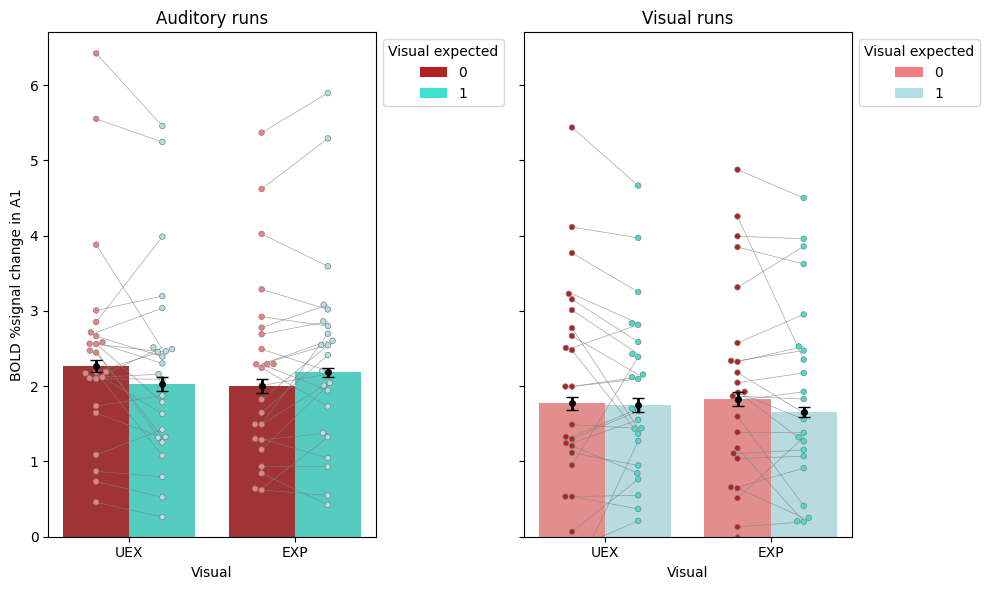

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
x = "v_pred"
y = "mean"
hue = "a_pred"

barplot_morey(multimodal_df[multimodal_df["attended_modality"] == "auditory"], x, y, hue, "Visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], barplot_plot=True, swarmplot_plot=True, within_lines=True, ax=axes[0])
axes[0].set_title("Auditory runs")
axes[0].set_ylabel(f"BOLD %signal change in {ROI}")
axes[0].set_xlabel("Visual")
axes[0].set_xticklabels(["UEX", "EXP"])
axes[0].set_ylim(0, 6.7)

barplot_morey(multimodal_df[multimodal_df["attended_modality"] == "visual"], x, y, hue, "Visual expected", ["lightcoral", "powderblue"], ["firebrick", "turquoise"], barplot_plot=True, swarmplot_plot=True, within_lines=True, ax=axes[1])
axes[1].set_title("Visual runs")
axes[1].set_xlabel("Visual")
axes[1].set_xticklabels(["UEX", "EXP"])

plt.tight_layout()
plt.savefig(f"figures/ROI/{ROI}_interaction.svg", dpi=300)

In [21]:
AnovaRM(multimodal_df[multimodal_df["attended_modality"] != "all"], y, subject='subj', within=[x, hue, "attended_modality"]).fit().summary()

,F Value,Num DF,Den DF,Pr > F
v_pred,0.2615,1.0000,24.0000,0.6138
a_pred,1.1828,1.0000,24.0000,0.2876
attended_modality,10.3409,1.0000,24.0000,0.0037
v_pred:a_pred,1.2843,1.0000,24.0000,0.2683
v_pred:attended_modality,0.2227,1.0000,24.0000,0.6412
a_pred:attended_modality,0.4059,1.0000,24.0000,0.5301
v_pred:a_pred:attended_modality,4.9899,1.0000,24.0000,0.0351


In [22]:
print("Anova auditory runs")
pg.rm_anova(dv=y, within=[x, hue], subject='subj', data=multimodal_df[multimodal_df["attended_modality"] == "auditory"])

Anova auditory runs


/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,v_pred,0.088175,1,24,0.088175,0.415151,0.525477,0.525477,0.000370,1.0
1,a_pred,0.022013,1,24,0.022013,0.176741,0.677929,0.677929,0.000092,1.0
2,v_pred * a_pred,1.123946,1,24,1.123946,6.922558,0.014637,0.014637,0.004695,1.0


In [23]:
print("Anova visual runs")
pg.rm_anova(dv=y, within=[x, hue], subject='subj', data=multimodal_df[multimodal_df["attended_modality"] == "visual"])

Anova visual runs


/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,v_pred,0.007549,1,24,0.007549,0.044825,0.834113,0.834113,0.000036,1.0
1,a_pred,0.232775,1,24,0.232775,1.284627,0.268236,0.268236,0.001113,1.0
2,v_pred * a_pred,0.136046,1,24,0.136046,0.595851,0.447700,0.447700,0.000651,1.0


In [24]:
print("Pairwise auditory runs")
pg.pairwise_tests(dv=y, within=[x, hue], subject='subj', data=multimodal_df[multimodal_df["attended_modality"] == "auditory"], padjust='fdr_bh')

Pairwise auditory runs


,Contrast,v_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,v_pred,-,0,1,True,True,0.644322,24.0,two-sided,0.525477,NaN,NaN,0.255,0.037651
1,a_pred,-,0,1,True,True,0.420406,24.0,two-sided,0.677929,NaN,NaN,0.229,0.018899
2,v_pred * a_pred,0,0,1,True,True,2.028510,24.0,two-sided,0.053744,0.063082,fdr_bh,1.21,0.149552
3,v_pred * a_pred,1,0,1,True,True,-1.948957,24.0,two-sided,0.063082,0.063082,fdr_bh,1.068,-0.115062


In [25]:
print("Pairwise visual runs")
pg.pairwise_tests(dv=y, within=[x, hue], subject='subj', data=multimodal_df[multimodal_df["attended_modality"] == "visual"], padjust='fdr_bh')

Pairwise visual runs


,Contrast,v_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,v_pred,-,0,1,True,True,0.211720,24.0,two-sided,0.834113,NaN,NaN,0.215,0.011878
1,a_pred,-,0,1,True,True,1.133414,24.0,two-sided,0.268236,NaN,NaN,0.375,0.065909
2,v_pred * a_pred,0,0,1,True,True,0.161395,24.0,two-sided,0.873133,0.873133,fdr_bh,0.213,0.015255
3,v_pred * a_pred,1,0,1,True,True,1.496946,24.0,two-sided,0.147444,0.294888,fdr_bh,0.565,0.112946
